# JOUR 1 - EXPLORATION ET FEATURE ENGINEERING

**Projet Fil Rouge - Prédiction de Churn Client**

**Objectifs du Jour 1**:
- Explorer et comprendre le dataset
- Créer un pipeline de preprocessing robuste
- Générer au minimum 10 nouvelles features avancées
- Établir une baseline de référence

**Durée estimée**: 7 heures

## 0. SETUP ET IMPORTS

In [1]:
!pip install kaggle -q

import os, json
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "issakouy", "key": "KGAT_200aaf88d8342fb11b1a4d2b8d4fa4bc"}, f)

!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d mnassrib/telecom-churn-datasets -p /content/ --unzip

import os
print(os.listdir('/content/'))

Dataset URL: https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets
License(s): copyright-authors
100% 99.5k/99.5k [00:00<00:00, 57.4MB/s]

['.config', 'churn-bigml-20.csv', 'churn-bigml-80.csv', 'sample_data']


In [2]:
# Imports essentiels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, recall_score)

import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## PARTIE 1.1 - EXPLORATION APPROFONDIE (2h)

### Mission 1.1.1 - Chargement et Première Vue

In [3]:
!pip install kaggle -q

import os, json
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "issakouy", "key": "KGAT_200aaf88d8342fb11b1a4d2b8d4fa4bc"}, f)

!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d blastchar/telco-customer-churn -p /content/ --unzip

import os
print(os.listdir('/content/'))

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 95.0MB/s]

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'churn-bigml-20.csv', 'churn-bigml-80.csv', 'sample_data']


In [4]:
# Charger le dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape du dataset: {df.shape}")
df.head()

Shape du dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Informations générales sur le dataset
# TODO: Afficher les informations (types, valeurs non nulles)
...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistiques descriptives
# TODO: Afficher les statistiques descriptives pour les variables numériques
...

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Mission 1.1.2 - Analyse de la Target

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


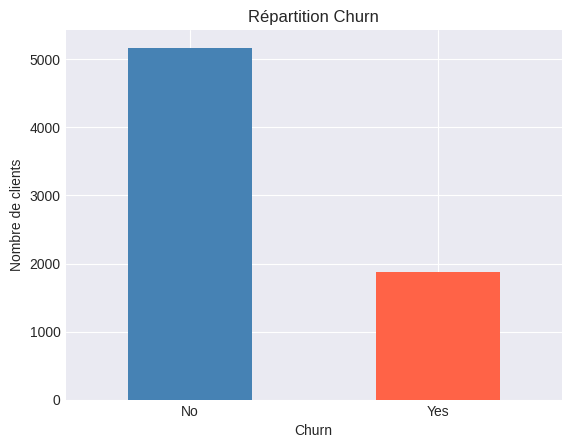

In [7]:
# Distribution de la target
# TODO: Afficher le nombre et le pourcentage de Churn (Yes/No)
...

# TODO: Visualiser avec un graphique en barres
...

# Nombre et pourcentage
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

# Graphique
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Répartition Churn')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.show()

**Question**: Le dataset est-il déséquilibré ? Quel est le ratio ?

**Réponse**: Churn : No = 5174 (73.5%) / Yes = 1869 (26.5%) → Oui le dataset est déséquilibré, ratio ~2.77:1. C'est exactement ce que le sujet mentionne.

### Mission 1.1.3 - Valeurs Manquantes et Qualité des Données

In [8]:
# Valeurs manquantes
# TODO: Identifier les colonnes avec valeurs manquantes
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [9]:
# Gestion des valeurs manquantes dans TotalCharges
# TODO: Convertir TotalCharges en numérique et traiter les espaces vides
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'], inplace=True)
print("TotalCharges corrigé ✅")
print(df['TotalCharges'].isnull().sum(), "valeurs manquantes restantes")

TotalCharges corrigé ✅
0 valeurs manquantes restantes


### Mission 1.1.4 - Analyse Univariée

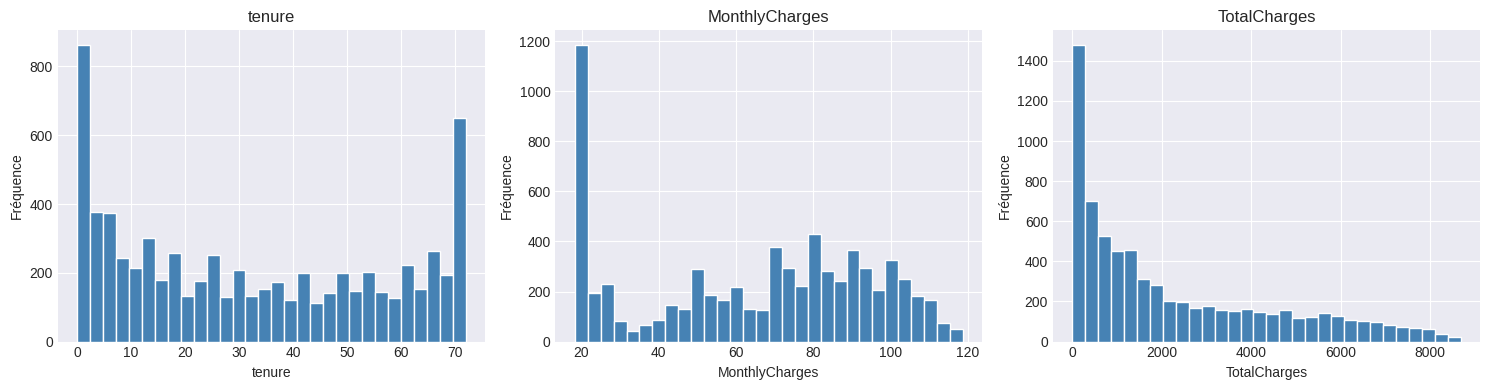

In [10]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()

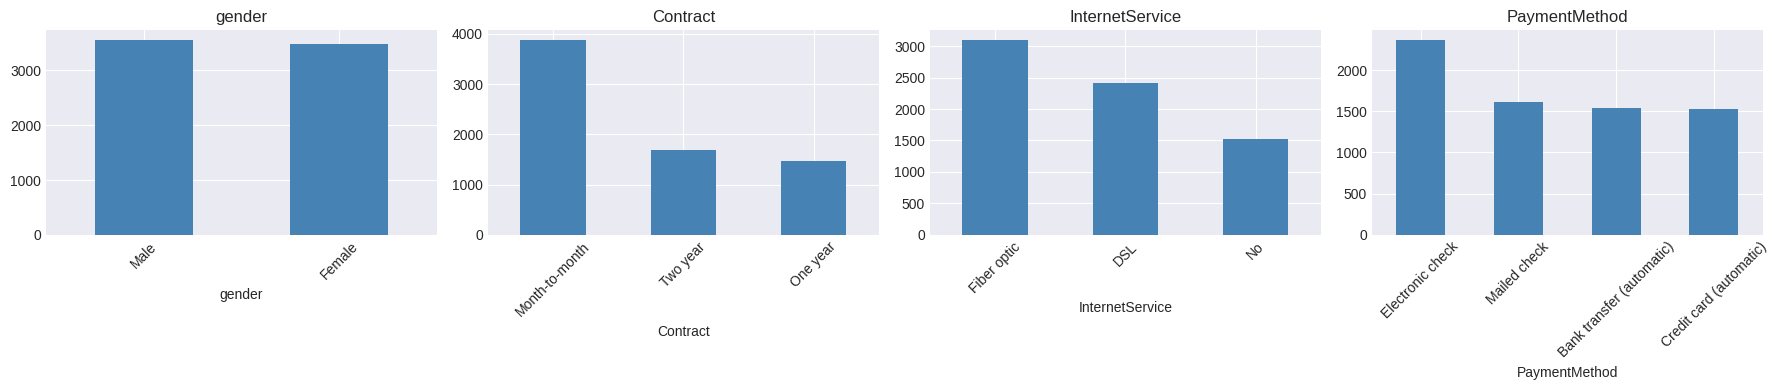

In [11]:
categorical_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Mission 1.1.5 - Analyse Bivariée

In [12]:
# Taux de churn par catégorie
# TODO: Calculer le taux de churn pour chaque variable catégorielle
# Exemple pour 'Contract':

for col in ['Contract', 'InternetService', 'PaymentMethod', 'gender']:
    taux = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    print(f"\nTaux de churn par {col}:")
    print(taux.sort_values(ascending=False))


Taux de churn par Contract:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Taux de churn par InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

Taux de churn par PaymentMethod:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64

Taux de churn par gender:
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


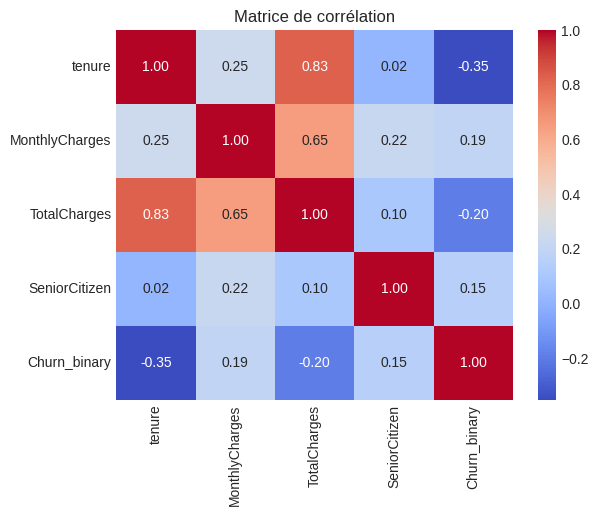

Ellipsis

In [13]:
# Corrélation entre variables numériques et churn
# TODO: Encoder Churn en binaire (0/1) et calculer les corrélations
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()
# TODO: Matrice de corrélation
...

### Mission 1.1.6 - Insights Métier

**TODO**: À partir de votre exploration, répondez aux questions suivantes:

1. **Quels sont les 3 profils clients les plus à risque de churn ?**
   - Contrat Month-to-month → 42.7% de churn
   - Internet Fiber optic → 41.9% de churn
   - Paiement Electronic check → 45.3% de churn

2. **Quel est l'impact financier mensuel moyen du churn ?**
   - Perte mensuelle moyenne par churner : ~74$
   - Perte mensuelle totale estimée : ~138 000$ (74$ × 1869 churners)

3. **Formulez 3 hypothèses métier à tester:**
   - H1: Les clients avec contrat Month-to-month churnent plus que ceux avec contrat annuel
   - H2: Les clients Fiber optic avec charges élevées ont plus de risque de churner
   - H3: Les clients avec moins de 6 mois d'ancienneté ont un risque de churn plus élevé

## PARTIE 1.2 - FEATURE ENGINEERING AVANCÉ (3h)

### Mission 1.2.1 - Créer au minimum 10 nouvelles features

#### A. Features de Ratio

In [20]:
# Features de Ratio
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['ChargesPerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
df['ChargeRatio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)

print(" Features de ratio créées")
df[['AvgMonthlySpend', 'ChargesPerTenure', 'ChargeRatio']].head()

✅ Features de ratio créées


,AvgMonthlySpend,ChargesPerTenure,ChargeRatio
0,14.925000,14.925000,0.967585
1,53.985714,1.627143,32.605695
2,36.050000,17.950000,1.971741
3,40.016304,0.919565,42.511547
4,50.550000,23.566667,2.115063


#### B. Features d'Agrégation

In [21]:
# Features d'Agrégation
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)
df['EngagementScore'] = df['tenure'] * df['TotalServices']

print(" Features d'agrégation créées")
df[['TotalServices', 'EngagementScore']].head()

 Features d'agrégation créées


,TotalServices,EngagementScore
0,1,1
1,3,102
2,3,6
3,3,135
4,1,2


#### C. Features d'Interaction

In [22]:
# Features d'Interaction
df['Contract_Internet'] = df['Contract'] + '_' + df['InternetService']
df['Tenure_MonthlyCharges'] = df['tenure'] * df['MonthlyCharges']

print(" Features d'interaction créées")
df[['Contract_Internet', 'Tenure_MonthlyCharges']].head()

 Features d'interaction créées


,Contract_Internet,Tenure_MonthlyCharges
0,Month-to-month_DSL,29.85
1,One year_DSL,1936.30
2,Month-to-month_DSL,107.70
3,One year_DSL,1903.50
4,Month-to-month_Fiber optic,141.40


#### D. Features Binaires

In [23]:
# Features Binaires
df['IsNewCustomer'] = (df['tenure'] < 6).astype(int)
df['IsPremium'] = (df['MonthlyCharges'] > 80).astype(int)
df['SeniorFiber'] = ((df['SeniorCitizen'] == 1) & (df['InternetService'] == 'Fiber optic')).astype(int)

print(" Features binaires créées")
df[['IsNewCustomer', 'IsPremium', 'SeniorFiber']].head()

 Features binaires créées


,IsNewCustomer,IsPremium,SeniorFiber
0,1,0,0
1,0,0,0
2,1,0,0
3,0,0,0
4,1,0,0


#### E. Transformations Mathématiques (Optionnel)

In [24]:
# Transformations Mathématiques
df['LogMonthlyCharges'] = np.log1p(df['MonthlyCharges'])
df['LogTotalCharges'] = np.log1p(df['TotalCharges'])
df['Tenure_Squared'] = df['tenure'] ** 2

print(" Transformations mathématiques créées")
df[['LogMonthlyCharges', 'LogTotalCharges', 'Tenure_Squared']].head()

 Transformations mathématiques créées


,LogMonthlyCharges,LogTotalCharges,Tenure_Squared
0,3.429137,3.429137,1
1,4.059581,7.544597,1156
2,4.004602,4.692723,4
3,3.768153,7.518471,2025
4,4.272491,5.028148,4


#### F. Vérification des Features Créées

In [25]:
new_features = [
    'AvgMonthlySpend', 'ChargesPerTenure', 'ChargeRatio',
    'TotalServices', 'EngagementScore',
    'Contract_Internet', 'Tenure_MonthlyCharges',
    'IsNewCustomer', 'IsPremium', 'SeniorFiber',
    'LogMonthlyCharges', 'LogTotalCharges', 'Tenure_Squared'
]

print(f"Nombre de nouvelles features: {len(new_features)}")
print("Features créées:", new_features)
df[new_features].head()

Nombre de nouvelles features: 13
Features créées: ['AvgMonthlySpend', 'ChargesPerTenure', 'ChargeRatio', 'TotalServices', 'EngagementScore', 'Contract_Internet', 'Tenure_MonthlyCharges', 'IsNewCustomer', 'IsPremium', 'SeniorFiber', 'LogMonthlyCharges', 'LogTotalCharges', 'Tenure_Squared']


,AvgMonthlySpend,ChargesPerTenure,ChargeRatio,TotalServices,EngagementScore,Contract_Internet,Tenure_MonthlyCharges,IsNewCustomer,IsPremium,SeniorFiber,LogMonthlyCharges,LogTotalCharges,Tenure_Squared
0,14.925000,14.925000,0.967585,1,1,Month-to-month_DSL,29.85,1,0,0,3.429137,3.429137,1
1,53.985714,1.627143,32.605695,3,102,One year_DSL,1936.30,0,0,0,4.059581,7.544597,1156
2,36.050000,17.950000,1.971741,3,6,Month-to-month_DSL,107.70,1,0,0,4.004602,4.692723,4
3,40.016304,0.919565,42.511547,3,135,One year_DSL,1903.50,0,0,0,3.768153,7.518471,2025
4,50.550000,23.566667,2.115063,1,2,Month-to-month_Fiber optic,141.40,1,0,0,4.272491,5.028148,4


### Mission 1.2.2 - Pipeline de Preprocessing

In [26]:
# Supprimer customerID et colonnes inutiles
df = df.drop(['customerID'], axis=1)

# Séparer features et target
X = df.drop(['Churn', 'Churn_binary'], axis=1)
y = df['Churn_binary']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (7043, 32)
y shape: (7043,)


In [27]:
# Encodage des variables catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Shape après encodage: {X_encoded.shape}")
X_encoded.head()

Shape après encodage: (7043, 50)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ChargesPerTenure,TotalServices,EngagementScore,IsNewCustomer,IsPremium,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Internet_Month-to-month_Fiber optic,Contract_Internet_Month-to-month_No,Contract_Internet_One year_DSL,Contract_Internet_One year_Fiber optic,Contract_Internet_One year_No,Contract_Internet_Two year_DSL,Contract_Internet_Two year_Fiber optic,Contract_Internet_Two year_No
0,0,1,29.85,29.85,14.925000,14.925000,1,1,1,0,...,True,False,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,53.985714,1.627143,3,102,0,0,...,False,True,False,False,True,False,False,False,False,False
2,0,2,53.85,108.15,36.050000,17.950000,3,6,1,0,...,False,True,False,False,False,False,False,False,False,False
3,0,45,42.30,1840.75,40.016304,0.919565,3,135,0,0,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,50.550000,23.566667,1,2,1,0,...,True,False,True,False,False,False,False,False,False,False


## PARTIE 1.3 - BASELINE ET VALIDATION (2h)

### Mission 1.3.1 - Train/Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Train: (5634, 50), Test: (1409, 50)
Train churn rate: 26.54%
Test churn rate: 26.54%


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Normalisation effectuée")

 Normalisation effectuée


### Mission 1.3.2 - Modèle Baseline (Logistic Regression)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred = lr_baseline.predict(X_test_scaled)
y_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8455


In [31]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


ROC-AUC: 0.8455


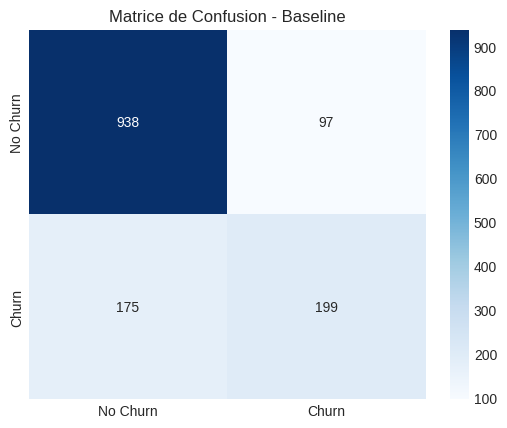

In [32]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Matrice de Confusion - Baseline')
plt.show()

### Mission 1.3.3 - Cross-Validation

In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_baseline, X_train_scaled, y_train, cv=skf, scoring='recall')

print(f"CV Recall: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores: {cv_scores}")

CV Recall: 0.5378 ± 0.0386
Scores: [0.52508361 0.48494983 0.55183946 0.60200669 0.52508361]


## SAUVEGARDE DES DONNÉES PRÉPARÉES

In [34]:
import joblib

# Sauvegarder le dataset enrichi
df.to_csv('/content/churn_engineered.csv', index=False)

# Sauvegarder les splits
joblib.dump([X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled],
            '/content/train_test_splits.pkl')

# Sauvegarder le scaler
joblib.dump(scaler, '/content/scaler.pkl')

print(" Tout sauvegardé !")
print("- churn_engineered.csv")
print("- train_test_splits.pkl")
print("- scaler.pkl")

 Tout sauvegardé !
- churn_engineered.csv
- train_test_splits.pkl
- scaler.pkl


## CONCLUSION JOUR 1

**Résumé des réalisations**:
- Dataset exploré: 7043 lignes, 21 colonnes
- Features créées: 13 (minimum 10 )
- Baseline Logistic Regression:
  - Recall: 0.53
  - Precision: 0.67
  - ROC-AUC: 0.8455

**Prochaines étapes (Jour 2)**:
- Benchmark de 5-6 modèles
- Gestion du déséquilibre (SMOTE, class_weight)
- Optimisation des hyperparamètres

In [35]:
from google.colab import files

files.download('/content/churn_engineered.csv')
files.download('/content/train_test_splits.pkl')
files.download('/content/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>